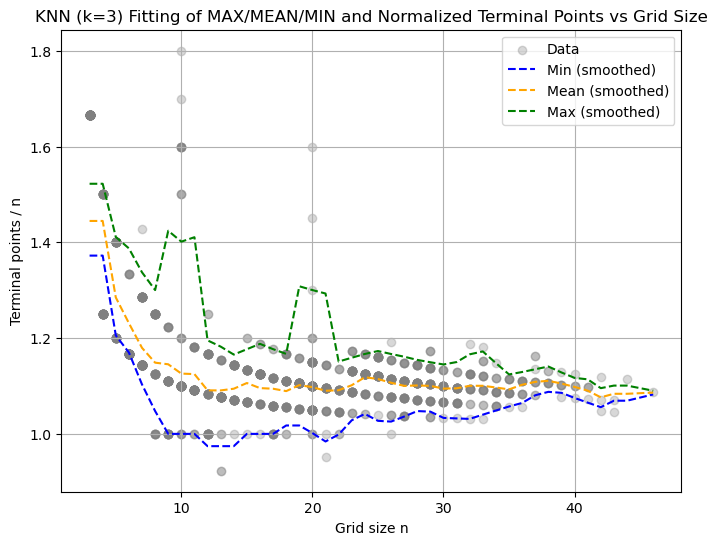

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# Load experiment results
csv_path = 'experiment_results.csv'
df = pd.read_csv(csv_path)

# Compute normalized terminal points
df['terminal_num_points_over_n'] = df['terminal_num_points'] / df['n']

# Aggregate statistics by grid size
stats = df.groupby('n')['terminal_num_points_over_n'].agg(['min','mean','max']).reset_index()

# Prepare data for smoothing
X = stats['n'].values.reshape(-1, 1)
min_y, mean_y, max_y = stats['min'].values, stats['mean'].values, stats['max'].values

# Fit KNN (k=3) and predict smoothed values
knn = KNeighborsRegressor(n_neighbors=3)
min_smooth = knn.fit(X, min_y).predict(X)
mean_smooth = knn.fit(X, mean_y).predict(X)
max_smooth = knn.fit(X, max_y).predict(X)

# Plot raw data, original, and smoothed curves
plt.figure(figsize=(8, 6))
plt.scatter(df['n'], df['terminal_num_points_over_n'], color='gray', alpha=0.3, label='Data')
plt.plot(stats['n'], min_smooth, linestyle='--', color='blue', label='Min (smoothed)')
plt.plot(stats['n'], mean_smooth, linestyle='--', color='orange', label='Mean (smoothed)')
plt.plot(stats['n'], max_smooth, linestyle='--', color='green', label='Max (smoothed)')

plt.xlabel('Grid size n')
plt.ylabel('Terminal points / n')
plt.title('KNN (k=3) Fitting of MAX/MEAN/MIN and Normalized Terminal Points vs Grid Size')
plt.legend()
plt.grid(True)
plt.show()

Smallest terminal points for each grid size:
     n  smallest_terminal_points  smallest_terminal_points_over_n  \
0    3                         5                         1.666667   
1    4                         5                         1.250000   
2    5                         6                         1.200000   
3    6                         7                         1.166667   
4    7                         8                         1.142857   
5    8                         8                         1.000000   
6    9                         9                         1.000000   
7   10                        10                         1.000000   
8   11                        11                         1.000000   
9   12                        12                         1.000000   
10  13                        12                         0.923077   
11  14                        14                         1.000000   
12  15                        15                         1

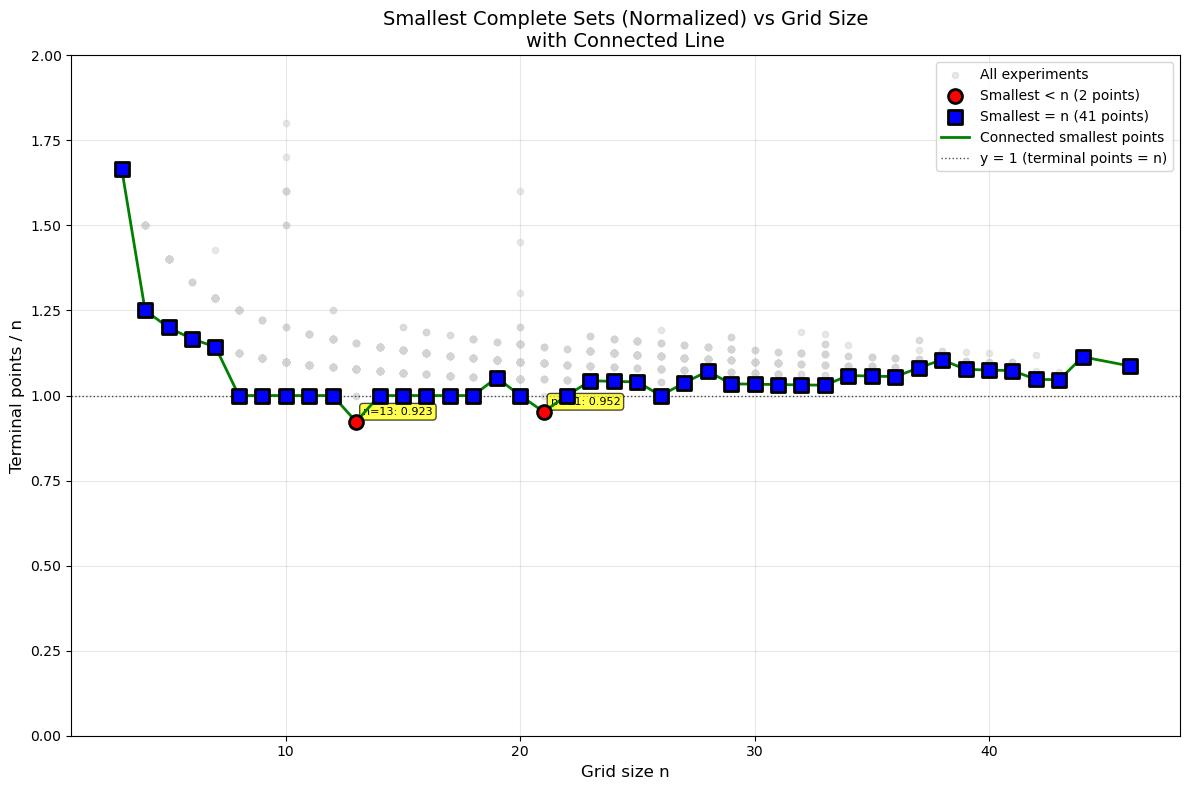


Smallest points connected with a simple line using 43 data points
Graph y-axis shows normalized values (terminal points / n) limited to range [0, 2]


In [9]:
import numpy as np

# Find the smallest terminal number of points for each grid size n
smallest_points_per_n = df.groupby('n')['terminal_num_points'].min().reset_index()
smallest_points_per_n.columns = ['n', 'smallest_terminal_points']

# Add normalized values (terminal points / n)
smallest_points_per_n['smallest_terminal_points_over_n'] = smallest_points_per_n['smallest_terminal_points'] / smallest_points_per_n['n']

# Add comparison with n
smallest_points_per_n['comparison'] = np.where(
    smallest_points_per_n['smallest_terminal_points'] < smallest_points_per_n['n'], 
    'smaller_than_n', 
    'equal_to_n'
)

# Filter the original dataframe to get only the rows with minimum terminal points
filtered_df = df.merge(smallest_points_per_n, 
                       left_on=['n', 'terminal_num_points'], 
                       right_on=['n', 'smallest_terminal_points'],
                       how='inner')

# Drop the redundant column but keep comparison
filtered_df = filtered_df.drop('smallest_terminal_points', axis=1)
filtered_df = filtered_df.sort_values(['n', 'terminal_num_points']).reset_index(drop=True)

# Separate points based on comparison with n
smaller_than_n = smallest_points_per_n[smallest_points_per_n['comparison'] == 'smaller_than_n']
equal_to_n = smallest_points_per_n[smallest_points_per_n['comparison'] == 'equal_to_n']

print("Smallest terminal points for each grid size:")
print(smallest_points_per_n)
print(f"\nPoints smaller than n: {len(smaller_than_n)}")
print(smaller_than_n[['n', 'smallest_terminal_points', 'smallest_terminal_points_over_n']])
print(f"\nPoints equal to n: {len(equal_to_n)}")
print(equal_to_n[['n', 'smallest_terminal_points', 'smallest_terminal_points_over_n']])

# Plot the results
plt.figure(figsize=(12, 8))

# Plot all data points (only those within y range 0-2)
df_filtered = df[(df['terminal_num_points_over_n'] >= 0) & (df['terminal_num_points_over_n'] <= 2)]
plt.scatter(df_filtered['n'], df_filtered['terminal_num_points_over_n'], color='lightgray', alpha=0.5, s=20, label='All experiments')

# Highlight smallest points based on comparison with n
plt.scatter(smaller_than_n['n'], smaller_than_n['smallest_terminal_points_over_n'], 
            color='red', s=100, marker='o', edgecolors='black', linewidth=2,
            label=f'Smallest < n ({len(smaller_than_n)} points)', zorder=5)

plt.scatter(equal_to_n['n'], equal_to_n['smallest_terminal_points_over_n'], 
            color='blue', s=100, marker='s', edgecolors='black', linewidth=2,
            label=f'Smallest = n ({len(equal_to_n)} points)', zorder=5)

# Connect the smallest points with a line (sorted by n)
smallest_points_sorted = smallest_points_per_n.sort_values('n')
plt.plot(smallest_points_sorted['n'], smallest_points_sorted['smallest_terminal_points_over_n'], 
         'green', linewidth=2, linestyle='-', marker='', 
         label='Connected smallest points', zorder=4)

# Add reference line y = 1 (when terminal points = n)
plt.axhline(y=1, color='black', linewidth=1, linestyle=':', alpha=0.7, label='y = 1 (terminal points = n)')

plt.xlabel('Grid size n', fontsize=12)
plt.ylabel('Terminal points / n', fontsize=12)
plt.title('Smallest Complete Sets (Normalized) vs Grid Size\nwith Connected Line', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Set y-axis range to 0-2
plt.ylim(0, 2)

# Add annotations for special points (only those within y range)
for _, row in smaller_than_n.iterrows():
    if 0 <= row['smallest_terminal_points_over_n'] <= 2:
        plt.annotate(f'n={int(row["n"])}: {row["smallest_terminal_points_over_n"]:.3f}', 
                    (row['n'], row['smallest_terminal_points_over_n']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\nSmallest points connected with a simple line using {len(smallest_points_per_n)} data points")
print(f"Graph y-axis shows normalized values (terminal points / n) limited to range [0, 2]")

In [13]:
# Output unique smallest terminal points data - one per grid size n
print("Unique smallest complete sets - One experiment per grid size:")
print("=" * 80)

# Get one representative experiment per grid size that achieved the minimum
# We'll take the first one if there are multiple experiments with the same minimum
unique_smallest = filtered_df.groupby('n').first().reset_index()

# Create full figure path by concatenating figure_dir and session_name
if 'session_name' in unique_smallest.columns and 'figure_dir' in unique_smallest.columns:
    unique_smallest['full_figure_path'] = unique_smallest['figure_dir'] + '/' + unique_smallest['session_name']
    display_columns = ['n', 'terminal_num_points', 'full_figure_path']
elif 'figure_dir' in unique_smallest.columns:
    display_columns = ['n', 'terminal_num_points', 'figure_dir']
else:
    # Check if there are other directory-related columns
    dir_columns = [col for col in unique_smallest.columns if 'dir' in col.lower()]
    if dir_columns:
        display_columns = ['n', 'terminal_num_points'] + dir_columns
    else:
        # Show key columns if no directory columns found
        key_columns = ['n', 'terminal_num_points']
        # Add some other useful columns if they exist
        for col in ['time_used', 'random_seed', 'terminal_num_points_over_n', 'session_name']:
            if col in unique_smallest.columns:
                key_columns.append(col)
        display_columns = key_columns

# Display the unique results
unique_display = unique_smallest[display_columns].copy()

# Sort by n for better readability
unique_display = unique_display.sort_values('n').reset_index(drop=True)

print(f"Total grid sizes: {len(unique_display)}")
print(f"Columns shown: {', '.join(display_columns)}")
print("\nData (one experiment per grid size):")
print(unique_display.to_string(index=False))

# Summary statistics
print(f"\nSummary:")
print(f"Grid sizes covered: {sorted(unique_display['n'].unique())}")
print(f"Range of smallest complete sets: {unique_display['terminal_num_points'].min()} to {unique_display['terminal_num_points'].max()}")

# Show the n vs terminal_num_points mapping clearly
print(f"\nGrid size → Smallest complete set mapping:")
for _, row in unique_display.iterrows():
    ratio = row['terminal_num_points'] / row['n']
    print(f"n={int(row['n']):2d} → {int(row['terminal_num_points']):2d} points (ratio: {ratio:.3f})")

# Show available columns for reference
print(f"\nAvailable columns in dataset: {list(unique_smallest.columns)}")
if 'full_figure_path' in unique_smallest.columns:
    print("\nFull figure paths for HPC3 access:")
    for _, row in unique_display.iterrows():
        print(f"n={int(row['n']):2d}: {row['full_figure_path']}")
elif 'session_name' in unique_smallest.columns:
    print("\nFigure directories with session names:")
    for _, row in unique_display.iterrows():
        session = row.get('session_name', 'N/A')
        fig_dir = row.get('figure_dir', 'N/A')
        print(f"n={int(row['n']):2d}: {fig_dir}/{session}")

Unique smallest complete sets - One experiment per grid size:
Total grid sizes: 43
Columns shown: n, terminal_num_points, full_figure_path

Data (one experiment per grid size):
 n  terminal_num_points                                                                                                            full_figure_path
 3                    5 /Users/luoninz1/063_Research/no-three-in-line/Code/RLMath/tests/test_mcts_smallest_complete_set/figure/20250808_001224_3by3
 4                    5                                 /dfs6/pub/luoninz1/RLMath/tests/test_mcts_smallest_complete_set/figure/20250808_005058_4by4
 5                    6 /Users/luoninz1/063_Research/no-three-in-line/Code/RLMath/tests/test_mcts_smallest_complete_set/figure/20250808_001225_5by5
 6                    7                                 /dfs6/pub/luoninz1/RLMath/tests/test_mcts_smallest_complete_set/figure/20250808_005103_6by6
 7                    8                                                           t